# MIMO Random Vibration

This page contains an example demonstrating some usages of SDynPy for
multiple-input, multiple-output (MIMO) random vibration control.  In this
example, we will:

1. Load in a demonstration model and apply forces to generate an environment
   to replicate.
2. Select instrumentation locations to use for the vibration control
3. Select shaker locations for the vibration test
4. Apply weighting to response and shaker locations to tune the test
5. Generate time histories to play for the test and apply them to the structure
6. Compare results against the specification.

## Imports

For this project, we will import the following modules, including the SDynPy
module.

In [1]:
import numpy as np # Used for numeric calculations
import sdynpy as sdpy # Used for structural dynamics features

We will also import ``geometry`` and a ``system`` from the 
[`beam_airplane`](#api:sdynpy.demo.beam_airplane)
demonstration project, which we will transform into a modal system containing 
modes below 50 Hz with 2% damping.

In [2]:
# Import the demonstration problem
from sdynpy.demo.beam_airplane import geometry,system
# Compute the modes of the system
shapes = system.eigensolution(maximum_frequency=50)
# Add Damping
shapes.damping = 0.02
# Compute a modal system
modal_system = shapes.system()

## Optimizing Instrumentation for Test

We will start by selecting a set of optimal instrumentation to use for control.
For this example, we will use the effective independence algorithm implemented in
[`optimize_degrees_of_freedom`](#api:sdynpy.ShapeArray.optimize_degrees_of_freedom).
This function starts with a [`ShapeArray`](#api:sdynpy.ShapeArray) with a
candidate set of degrees of freedom and iteratively
throws away the degrees of freedom with the smallest contribution to the
effective independence of the system.

In [3]:
sensors_to_keep = 10
candidate_dofs = sdpy.coordinate_array(geometry.node.id[:,np.newaxis],
                                        [1,2,3])
candidate_shapes = shapes.reduce(candidate_dofs)
test_shapes = candidate_shapes.optimize_degrees_of_freedom(sensors_to_keep,group_by_node=True)
control_dofs = np.unique(test_shapes.coordinate)

We can then plot the kept coordinates and reduce the shapes down to this set to
see how independent the shapes are.

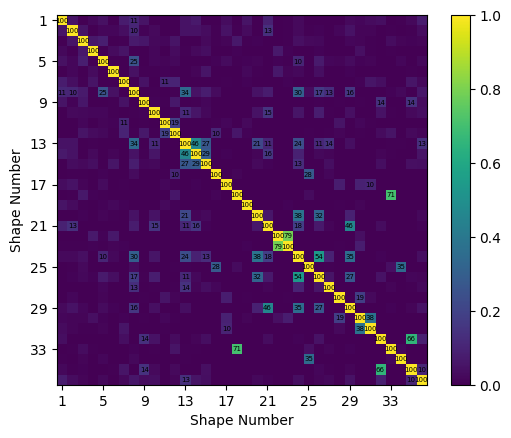

In [4]:
geometry.plot_coordinate(control_dofs,arrow_scale = 0.025,label_dofs = True)
test_shapes = shapes.reduce(control_dofs.node)

sdpy.matrix_plot(sdpy.shape.mac(test_shapes),text_size = 5);

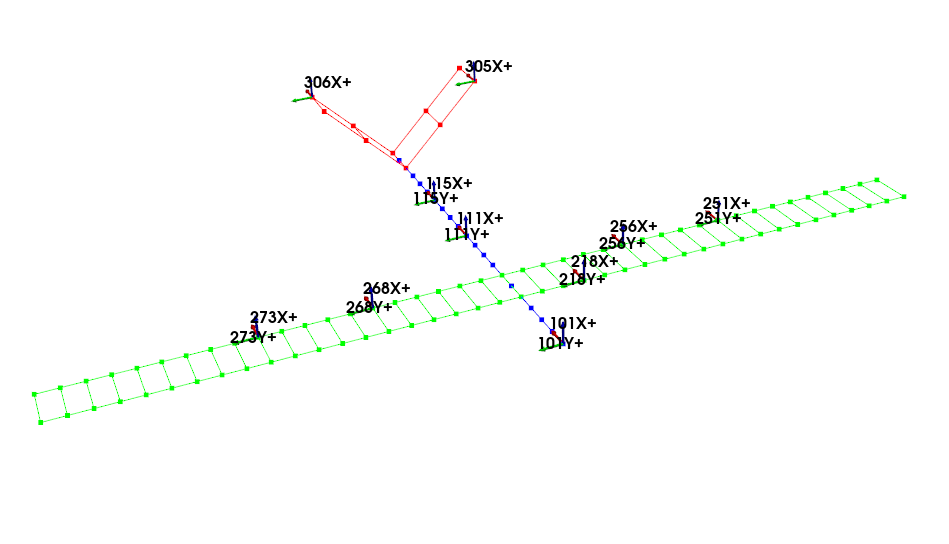

:::{note} Different Degrees of Freedom
Due to the symmetry of the airplane, the effective independence algorithm may select different degrees of freedom from one run to the next due to small round-off errors.  Don't panic if the sensors selected in your run are not the same as shown above.
:::

## Simulating an Environment

With the degrees of freedom selected, we will simulate an environment to attempt
to recreate.  For a real analysis, this may come from test data measured during
the environment, or a simulation of the environment.  In this case, we will
create an environment that assumes the airplane is excited on the leading edge
of the wing, the nose tip, and the tail.

In [5]:
environment_dofs = np.concatenate((
    sdpy.coordinate_array(np.arange(201,242),[1,3],force_broadcast=True),
    sdpy.coordinate_array(101,[1,2,3]),
    sdpy.coordinate_array([301,302,304,305],[1,2,3],force_broadcast=True)
    ))

geometry.plot_coordinate(environment_dofs,label_dofs=True,arrow_scale=0.025);

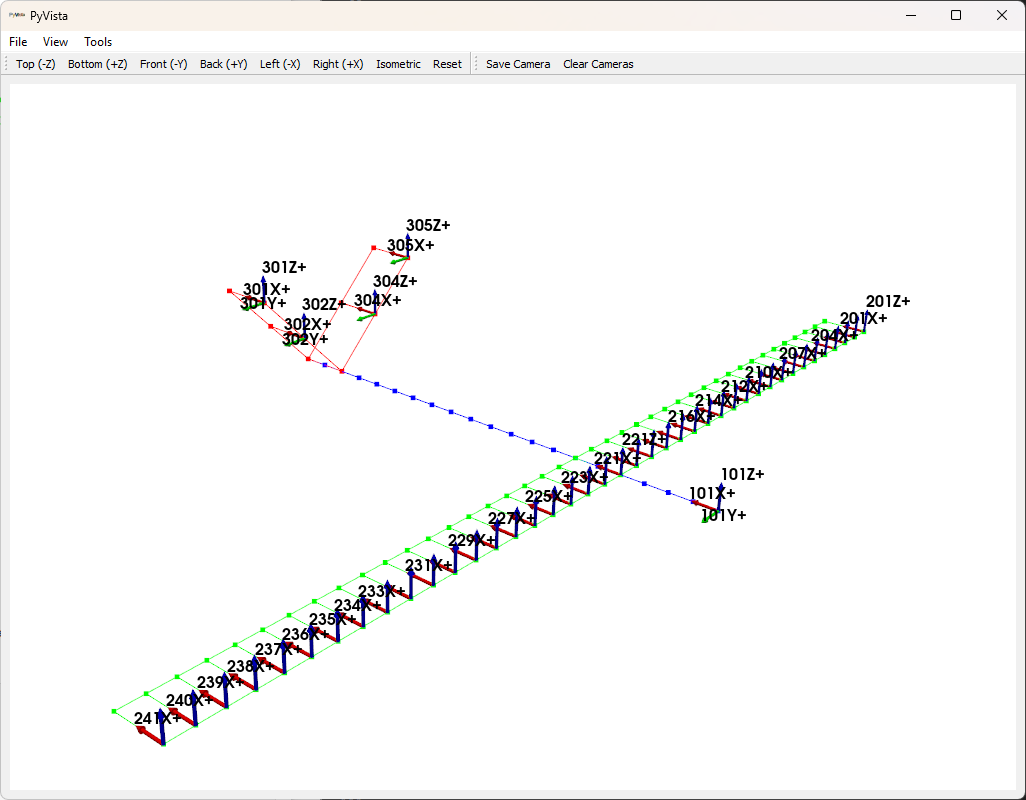

We can then construct frequency response functions between the environment
degrees of freedom and the control degrees of freedom in order to determine how
the airplane will respond at the control degrees of freedom to inputs from the
environment.  We can use [`GUIPlot`](#api:sdynpy.GUIPlot)
to plot the frequency response functions to quickly verify that they look right.

In [6]:
frequencies = (np.arange(1000)+1)*0.05
frfs = modal_system.frequency_response(frequencies,control_dofs.flatten(),environment_dofs,displacement_derivative = 2)

gp = sdpy.GUIPlot(frfs)

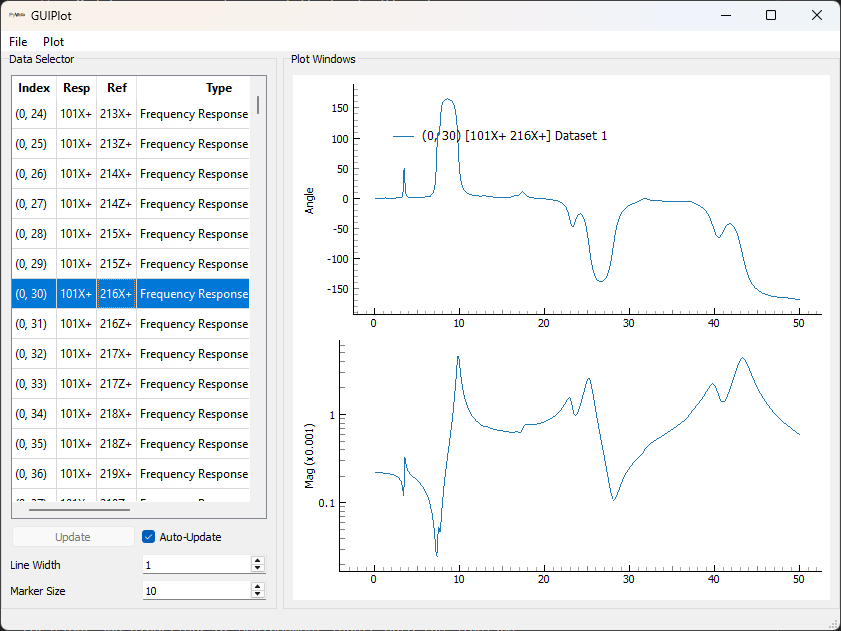

With the frequency response functions computed, we can create arbitrary inputs
to the environment degrees of freedom to apply to the structure.  We will define
these using a Power Spectral Density (PSD) matrix, represented by the 
[`PowerSpectralDensityArray`](#api:sdynpy.PowerSpectralDensityArray)
class.  We can use the
[`eye`](#api:sdynpy.PowerSpectralDensityArray.eye) method
to create a diagonal PSD matrix, meaning the inputs to the environment degrees
of freedom will be uncorrelated. Extra arguments to this method allow for
shaping and setting the level of the input PSD.

In [7]:
# Set up breakpoints to shape the PSD matrix
breakpoints = [0,10,20,30,40,50]
breakpoint_levels = [10,10,40,40,20,20]
# Compute the input PSDs
input_cpsd = sdpy.data.PowerSpectralDensityArray.eye(
    frequencies,environment_dofs,
    rms=1.5,full_matrix=True,
    breakpoint_frequencies = breakpoints,
    breakpoint_levels = breakpoint_levels)

We can then simulate the response to these inputs by using the 
[`mimo_forward`](#api:sdynpy.PowerSpectralDensityArray.mimo_forward)
method of the 
[`PowerSpectralDensityArray`](#api:sdynpy.PowerSpectralDensityArray)
object.  This performs the *forward* MIMO random vibration problem, which is to
project the input array through the frequency response functions to predict the
response of the structure.  This computation gives us the specification that
defines our simulated environment.

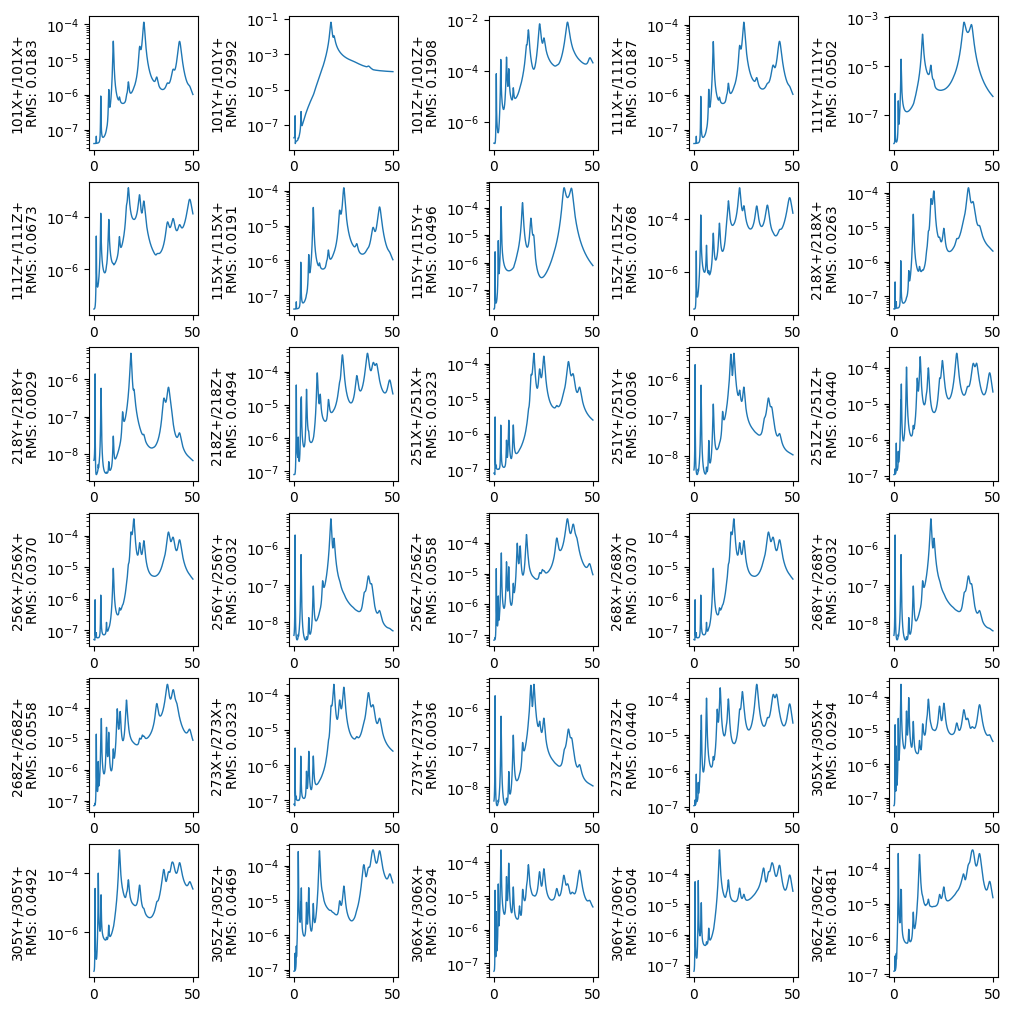

In [8]:
environment_specification = input_cpsd.mimo_forward(frfs)

environment_specification.plot_asds({'layout':'constrained','figsize':(10,10)});

## Selecting Shaker Excitation Locations

While a great deal of analysis can be performed to select the optimal shaker
locations for a MIMO vibration test, this example will simply select 4 shaker
locations to use to recreate the environment in the laboratory.  We can again
compute frequency response functions between the shaker locations and the
control degrees of freedom.

In [9]:
excitation_locations = sdpy.coordinate_array(
    string_array=['201X+','201Z+','233Z+','305Y+'])

geometry.plot_coordinate(excitation_locations,label_dofs=True)

control_frfs = modal_system.frequency_response(
    frequencies,control_dofs.flatten(),excitation_locations,
    displacement_derivative = 2)

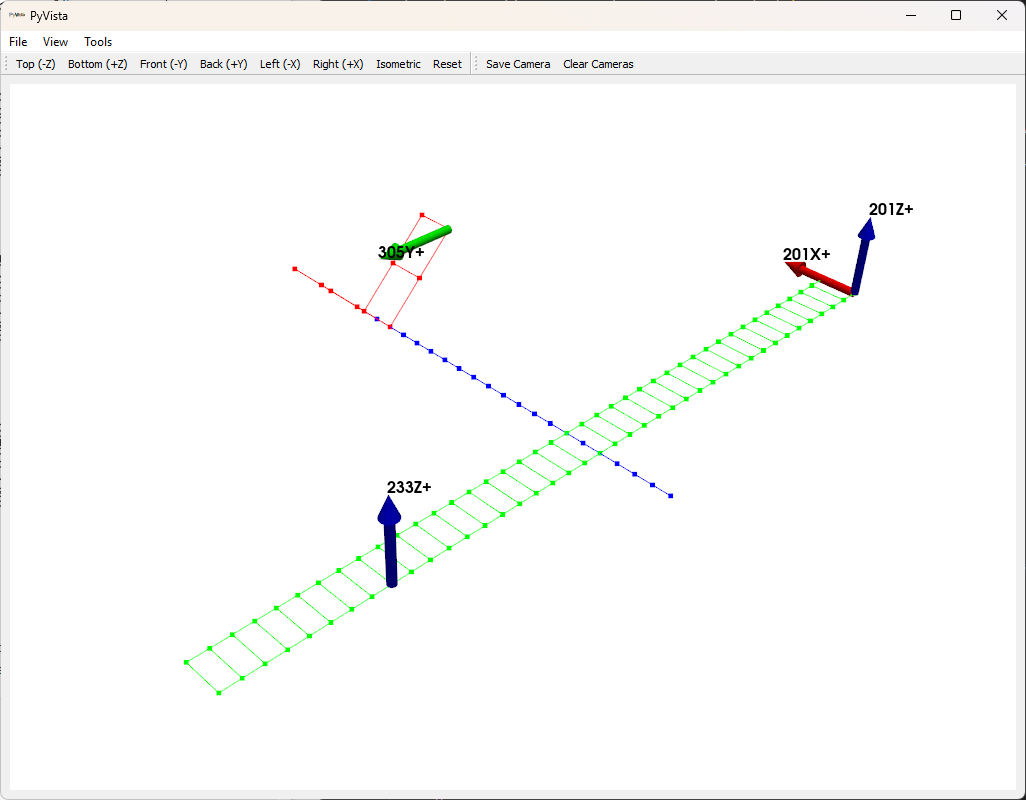



## Performing Vibration Control

This example will now walk through several solutions of the control problem
which highlight different strategies to perform the test.

### Simple Vibration Control using the Pseudoinverse

Perhaps the simplest vibration control solution utilizes the pseudoinverse
to compute the inverse of the frequency response function matrix to estimate
the inputs that should be applied to the system.  This can be done in a
straightforward way using the
[`mimo_inverse`](#api:sdynpy.PowerSpectralDensityArray.mimo_inverse)
method of the
[`PowerSpectralDensityArray`](#api:sdynpy.PowerSpectralDensityArray).
Combining this with the 
[`mimo_forward`](#api:sdynpy.PowerSpectralDensityArray.mimo_forward)
method allows computation of predicted response in two lines of code, first
computing the estimated inputs to the system, and then passing those inputs
through the frequency response function matrix.

In [10]:
input_cpsd = environment_specification.mimo_inverse(control_frfs)
control_predictions = input_cpsd.mimo_forward(control_frfs)

The inputs are being computed using the standard method


There are 30 x 30 = 900 functions in the specification, each with 1000 frequency
lines, so comparing two vibration responses is non-trivial.  SDynPy offers a
few built-in ways to compare PSD matrices.  The 
[`error_summary`](#api:sdynpy.PowerSpectralDensityArray.error_summary)
method of the
[`PowerSpectralDensityArray`](#api:sdynpy.PowerSpectralDensityArray)
produces plots of all of the auto-power spectral densities (APSD), which is the
diagonal of the PSD.  This focuses mainly on the levels at each control degree
of freedom and ignores the relationships between the control degrees of freedom.
Also plotted are global error metrics.  APSDs and level for each channel can be
plotted using the 
[`compare_asds`](#api:sdynpy.PowerSpectralDensityArray.compare_asds)
static method of the
[`PowerSpectralDensityArray`](#api:sdynpy.PowerSpectralDensityArray)
class.  This is useful for plotting and comparing the input levels required to run the test.

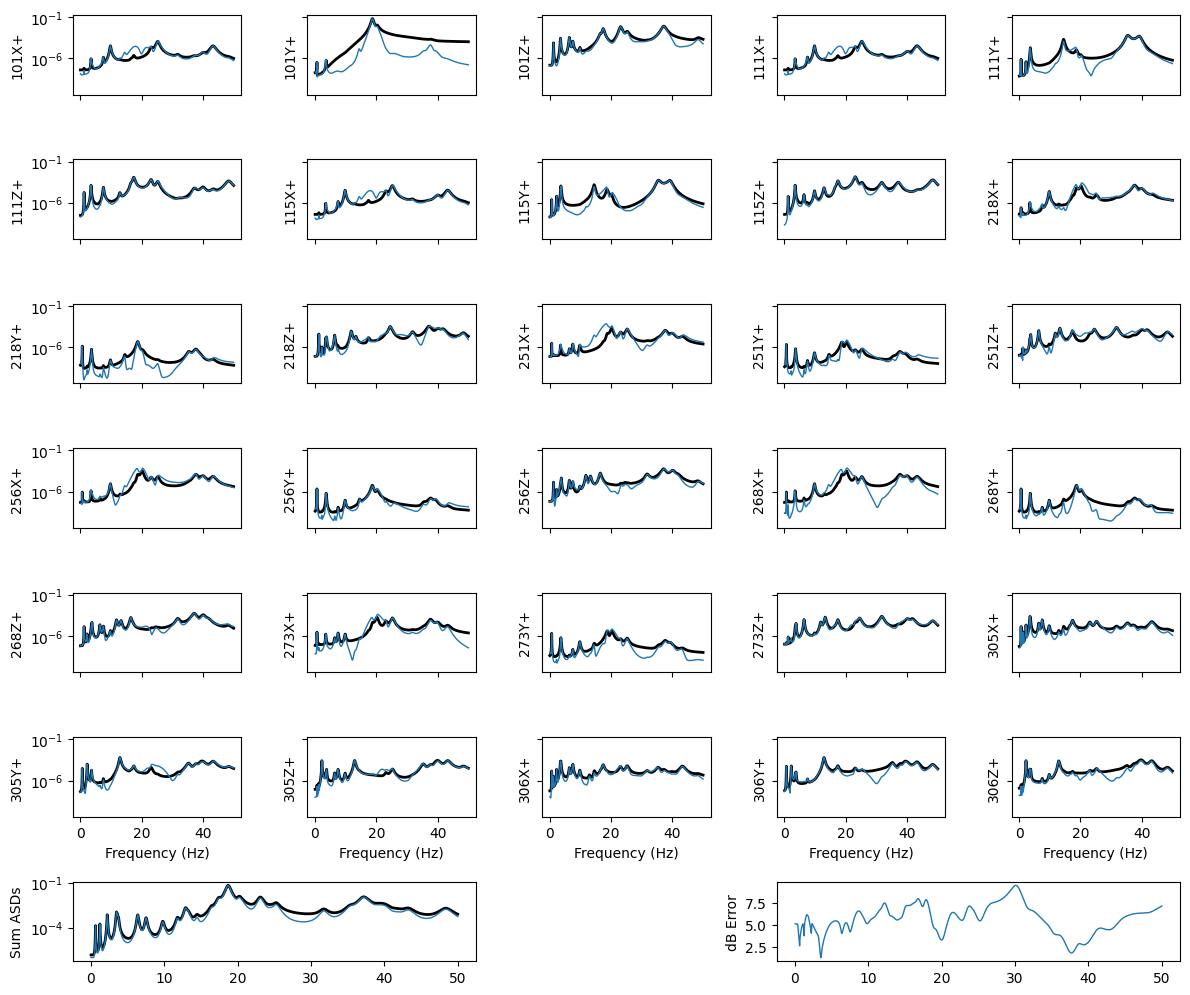

In [11]:
environment_specification.error_summary(Pseudoinverse=control_predictions,
                                        figure_kwargs={'figsize':(12,10)});

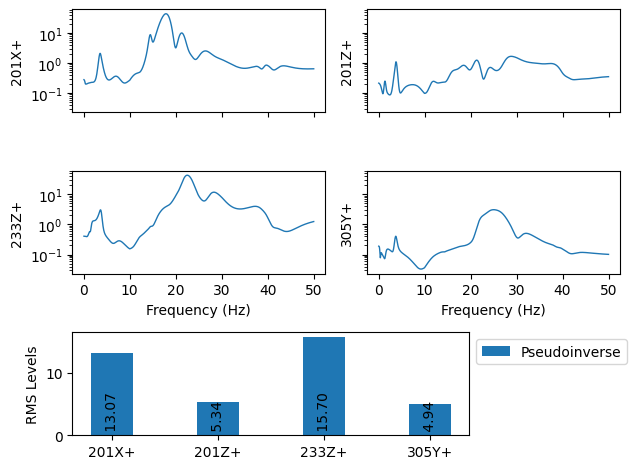

In [12]:
sdpy.data.PowerSpectralDensityArray.compare_asds(Pseudoinverse=input_cpsd)

### Tikhonov Regularization

Many times it is useful to regularize the solution to a MIMO vibration control
problem, as the inversion of the transfer function matrix can be ill-conditioned.
The [`mimo_inverse`](#api:sdynpy.PowerSpectralDensityArray.mimo_inverse)
method of the
[`PowerSpectralDensityArray`](#api:sdynpy.PowerSpectralDensityArray)
class accepts various weighting and regularization parameters, which results in
the general equation

\begin{equation}
\mathbf{H}^+ = \left(\mathbf{H}^H\mathbf{W}^H\mathbf{W}\mathbf{H}+\lambda\mathbf{\Sigma}\right)^{-1}\mathbf{H}^H\mathbf{W}^H\mathbf{W}
\end{equation}

where $\mathbf{H}$ is the frequency response function matrix,
$\mathbf{W}$ is a response weighting matrix, $\lambda$ is the input
regularization parameter, and $\mathbf{\Sigma}$ is the input weighting
matrix.  For Tikhonov regularization, the input weighting matrix is set to the
identity matrix.  We can then adjust the input regularization parameter $\lambda$
to tune the amount of regularization in the solution.  These parameters are passed
to the 
[`mimo_inverse`](#api:sdynpy.PowerSpectralDensityArray.mimo_inverse)
method.  The forward problem is performed as usual.

SDynPy provides the [`Matrix`](#api:sdynpy.Matrix) class
to specify the weighting matrices.  This class is essentially a matrix that also
keeps track of which degrees of freedom are represented by the rows and
columns of the matrix.  This ensures that bookkeeping is fast and easy in
SDynPy.  For the Tikhonov weighting, we can use the helper method 
[`eye`](#api:sdynpy.Matrix.eye), which generates a diagonal
matrix given the coordinates to use.  We will specify the coordinates as the 
shaker excitation degrees of freedom.

In [13]:
input_weighting_matrix_tikhonov = sdpy.Matrix.eye(excitation_locations)
input_weighting_scale_tikhonov = 1e-4

input_cpsd_tikhonov = environment_specification.mimo_inverse(
    control_frfs,
    method='tikhonov',
    regularization_weighting_matrix = input_weighting_matrix_tikhonov,
    regularization_parameter = input_weighting_scale_tikhonov)

control_predictions_tikhonov = input_cpsd_tikhonov.mimo_forward(
    control_frfs)

The inputs are being computed using the tikhonov method


We can compare the two solutions by passing additional arguments into the 
[`error_summary`](#api:sdynpy.PowerSpectralDensityArray.error_summary)
and 
[`compare_asds`](#api:sdynpy.PowerSpectralDensityArray.compare_asds)
methods.

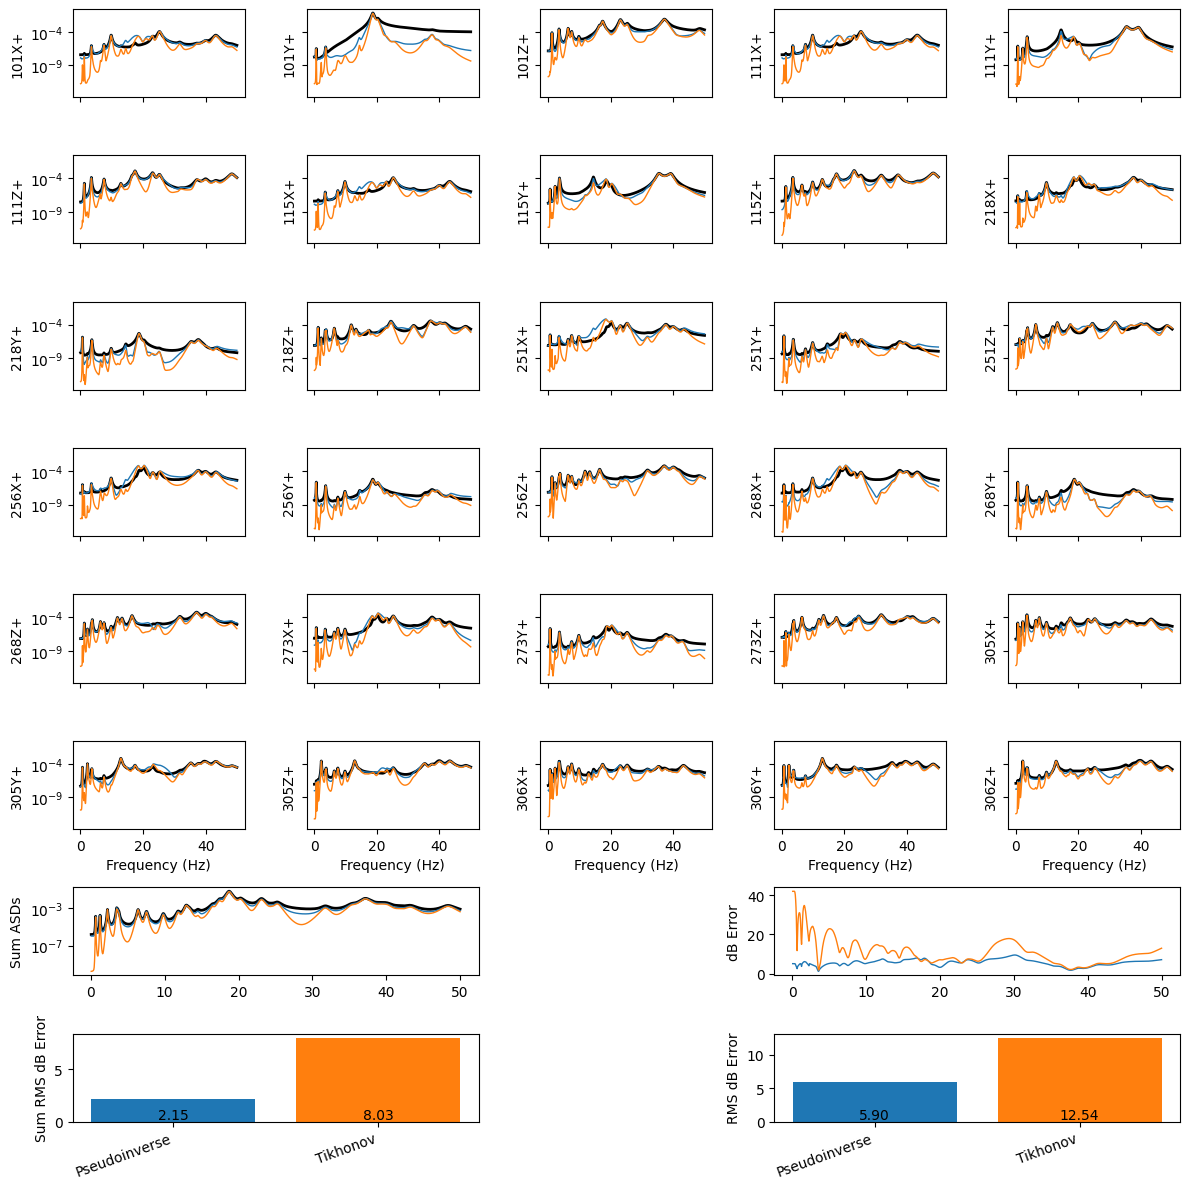

In [14]:
environment_specification.error_summary(Pseudoinverse=control_predictions,
                                        Tikhonov=control_predictions_tikhonov,
                                        figure_kwargs={'figsize':(12,12)});

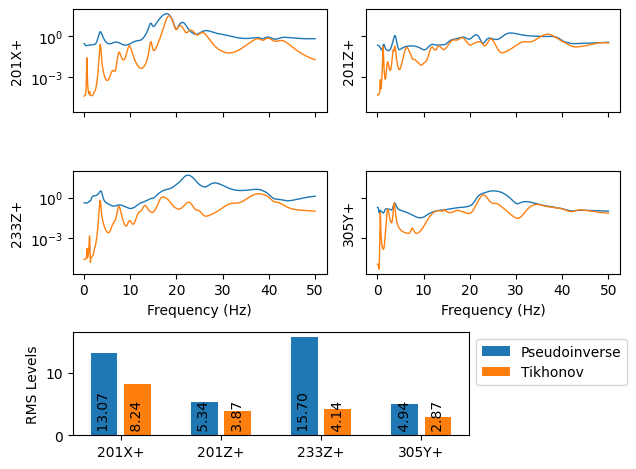

In [15]:
sdpy.data.PowerSpectralDensityArray.compare_asds(Pseudoinverse=input_cpsd,
                                                 Tikhonov = input_cpsd_tikhonov)

Note that the required input force is much lower at the expense of less
accuracy in the controlled solution.

### Weighting the Shakers

Rather than simply setting the input weighting matrix to the identity matrix,
we can instead set it to other values to weight the inputs.  In this case,
we will set the diagonal of the weighting matrix to the root-mean-square (RMS)
input levels required by the pseudoinverse control.  We must also adjust the
regularization parameter appropriately because the scale of the weighting matrix
has changed significantly.

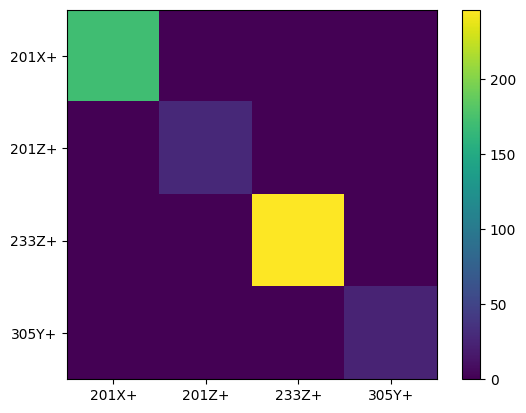

In [16]:
input_weighting_matrix_shaker_eq = sdpy.Matrix.eye(excitation_locations)
input_weighting_matrix_shaker_eq.matrix *= input_cpsd.rms()**2
input_weighting_scale_shaker_eq = 5e-7

input_weighting_matrix_shaker_eq.plot()

We can then solve the control problem with this new weighting and compare the
results against the previous strategies.

In [17]:
input_cpsd_shaker_eq = environment_specification.mimo_inverse(
    control_frfs,
    method='tikhonov',
    regularization_weighting_matrix = input_weighting_matrix_shaker_eq,
    regularization_parameter = input_weighting_scale_shaker_eq)

control_predictions_shaker_eq = input_cpsd_shaker_eq.mimo_forward(
    control_frfs)

The inputs are being computed using the tikhonov method


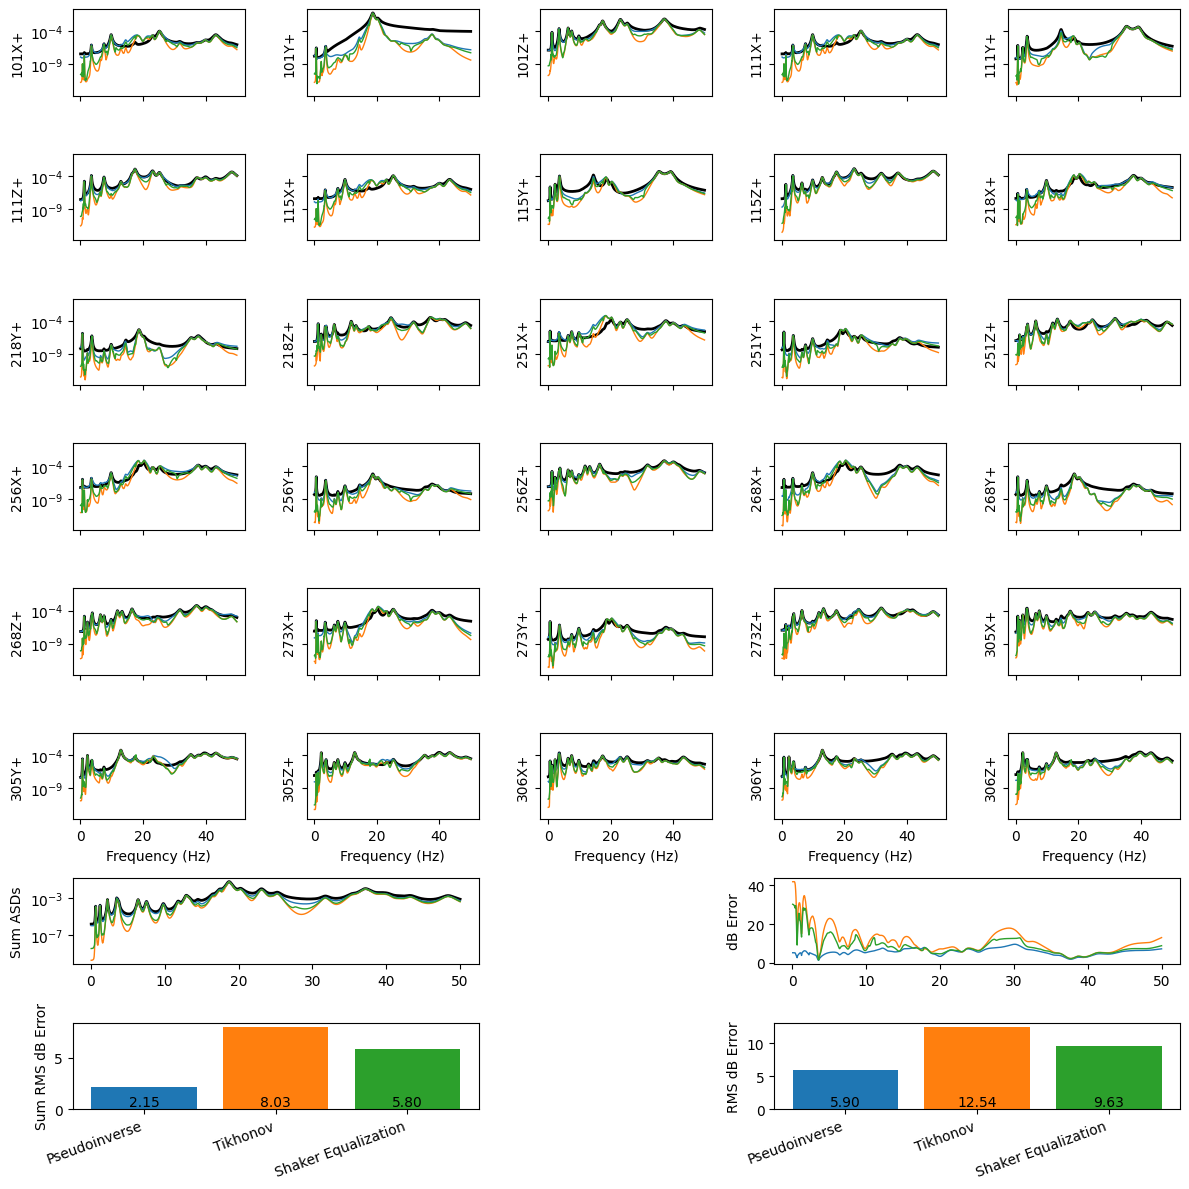

In [18]:
environment_specification.error_summary(Pseudoinverse=control_predictions,
                                        Tikhonov=control_predictions_tikhonov,
                                        Shaker_Equalization = control_predictions_shaker_eq,
                                        figure_kwargs={'figsize':(12,12)});

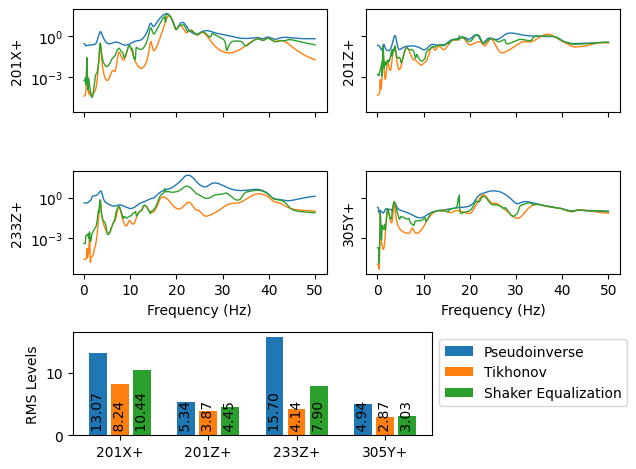

In [19]:
sdpy.data.PowerSpectralDensityArray.compare_asds(Pseudoinverse=input_cpsd,
                                                 Tikhonov = input_cpsd_tikhonov,
                                                 Shaker_Equalization = input_cpsd_shaker_eq)

We can see that we have improved the accuracy of the Tikhonov solution while
still keeping the required forces lower than the initial case.

### Response Weighting

Another strategy when performing vibration control is to weight the responses.
This makes the least-squares solution apply larger penalty factors to errors at
certain degrees of freedom.  For example, we may note that the response at 
degree of freedom ``101Y+`` is particularly poor, so we may want to apply
weighting to that degree of freedom to force the least squares solution to
consider errors on that degree of freedom more seriously.

We can again construct a [`Matrix`](#api:sdynpy.Matrix)
object, this time containing the control degrees of freedom rather than the
shaker degrees of freedom.  We can then specify that the degree of freedom
``101Y+`` should be weighted 10 times that of the other degrees of freedom.

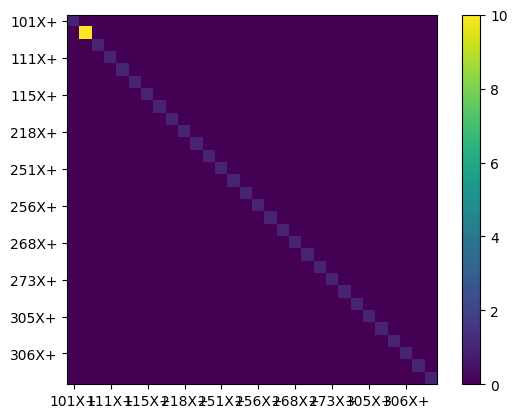

In [20]:
response_weighting_matrix = sdpy.Matrix.eye(control_dofs.flatten())
coordinate_to_improve = sdpy.coordinate_array(string_array=['101Y+'])
response_weighting_matrix[coordinate_to_improve,coordinate_to_improve] = 10
response_weighting_matrix.plot()

Note that we were able to index the [`Matrix`](#api:sdynpy.Matrix)
object using a [`CoordinateArray`](#api:sdynpy.CoordinateArray)
object, which handles the bookkeeping automatically.

In [21]:
input_cpsd_weighting = environment_specification.mimo_inverse(
    control_frfs,
    response_weighting_matrix=response_weighting_matrix)

control_predictions_weighting = input_cpsd_weighting.mimo_forward(control_frfs)

The inputs are being computed using the standard method


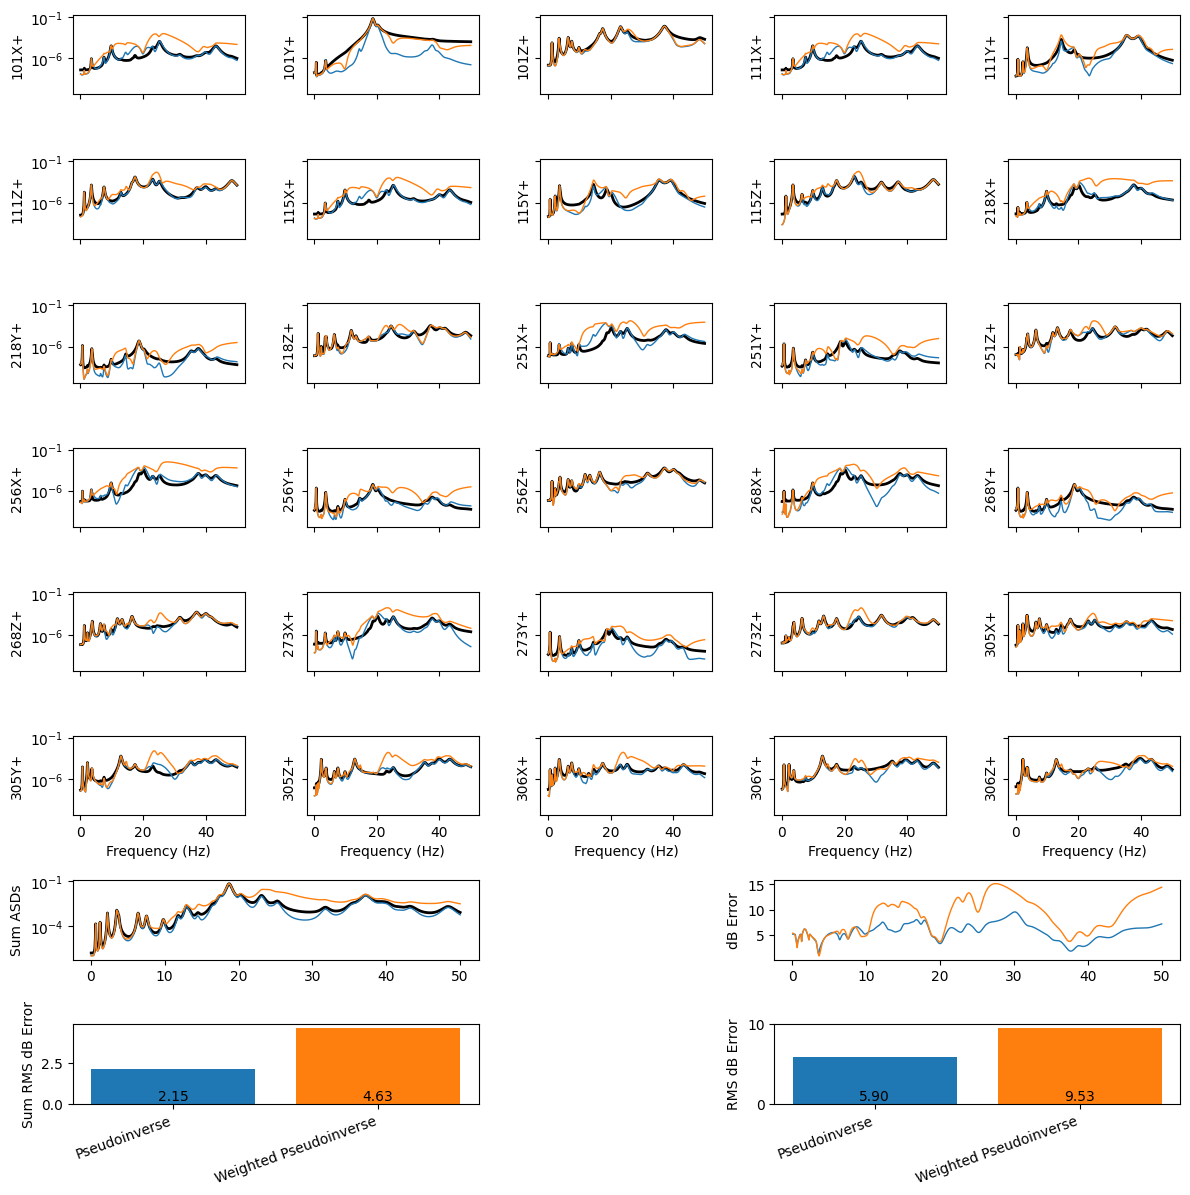

In [22]:
environment_specification.error_summary(Pseudoinverse=control_predictions,
                                        Weighted_Pseudoinverse=control_predictions_weighting,
                                        figure_kwargs={'figsize':(12,12)});

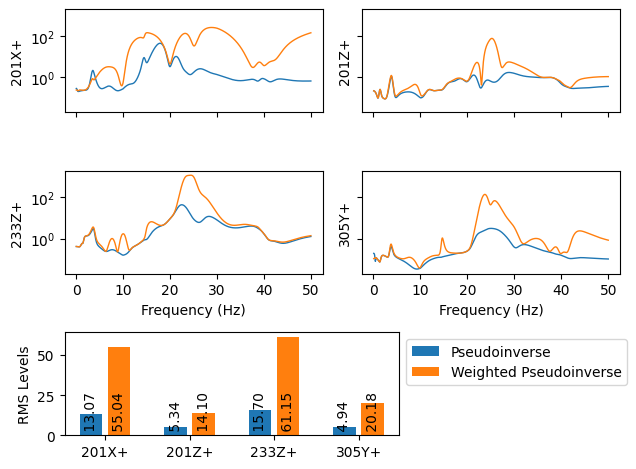

In [23]:
sdpy.data.PowerSpectralDensityArray.compare_asds(Pseudoinverse=input_cpsd,
                                                 Weighted_Pseudoinverse = input_cpsd_weighting)

While the accuracy of the entire solution on average has been degraded, the
response of the ``101Y+`` degree of freedom has significantly improved.  This,
however, requires significantly more input force to achieve, as it is attempting
to drive the structure in a way that it does not want to be driven.

### Buzz Test Method

A final approach considered here is the so-called **buzz test** approach, which
modifies the specification to more closely match the structure being tested.
In this approach, the structure is 'buzzed' with uncorrelated white noise at the input
locations to attempt to determine the preferred phasing and coherence between
the control degrees of freedom.  This is then used to modify the environment
specification: the APSD quantites on the diagonal are kept identical, but the
off diagonal terms are modified to match the coherence and phase of the buzz
test.  This approach is handled gracefully by SDynPy.  We can first create our
'buzz' inputs by creating an identity matrix for the specification using the
[`eye`](#api:sdynpy.PowerSpectralDensityArray.eye) method of
the
[`PowerSpectralDensityArray`](#api:sdynpy.PowerSpectralDensityArray)
class.  We can then pass it through the forward control problem using 
[`mimo_forward`](#api:sdynpy.PowerSpectralDensityArray.mimo_forward),
and compute the coherence and phase of the response using methods
[`coherence`](#api:sdynpy.PowerSpectralDensityArray.coherence)
and
[`angle`](#api:sdynpy.PowerSpectralDensityArray.angle),
respectively.  We can then modify the coherence and phase of the existing
specification using the
[`set_coherence_phase`](#api:sdynpy.PowerSpectralDensityArray.set_coherence_phase)
method of the 
[`PowerSpectralDensityArray`](#api:sdynpy.PowerSpectralDensityArray)
class.

In [24]:
# Perform buzz test to get coherence and phase of responses
buzz_input_cpsd = sdpy.data.PowerSpectralDensityArray.eye(
    frequencies,excitation_locations,full_matrix=True)

buzz_prediction = buzz_input_cpsd.mimo_forward(control_frfs)
buzz_coherence = buzz_prediction.coherence()
buzz_phase = buzz_prediction.angle()

modified_environment_specification = environment_specification.set_coherence_phase(
    buzz_coherence,buzz_phase)

We can then plot the specification to see how it has been changed.  Note that
we will not plot the entire 30 x 30 specification, as this is 900 functions.
We will instead only plot the first 6 x 6 portion, which will allow us to see
the trends in how the specification has been modified.  We can plot the
magnitude, phase, and coherence using the 
[`plot_magnitude_coherence_phase`](#api:sdynpy.PowerSpectralDensityArray.plot_magnitude_coherence_phase)
method of the
[`PowerSpectralDensityArray`](#api:sdynpy.PowerSpectralDensityArray)
class.  We can additionally pass in a second set of data to compare on the plots.

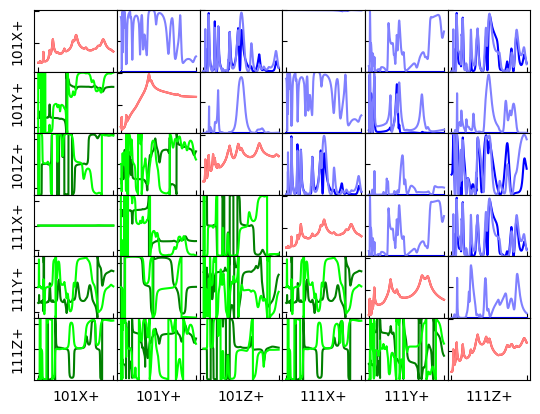

In [25]:
environment_specification[:6,:6].plot_magnitude_coherence_phase(
    modified_environment_specification[:6,:6]);

Here we see the comparison between the original specification (dark lines) and buzz-modified
specification (light lines) showing the magnitude (diagonal, red) unchanged
while the phase (lower triangle, green) and coherence (upper triangle, blue)
have been modified to be more accomodating to the structure being tested.

We can then control to this new specification while comparing results back to
the old specification.

In [26]:
input_cpsd_buzz = modified_environment_specification.mimo_inverse(control_frfs)
control_predictions_buzz = input_cpsd_buzz.mimo_forward(control_frfs)

The inputs are being computed using the standard method


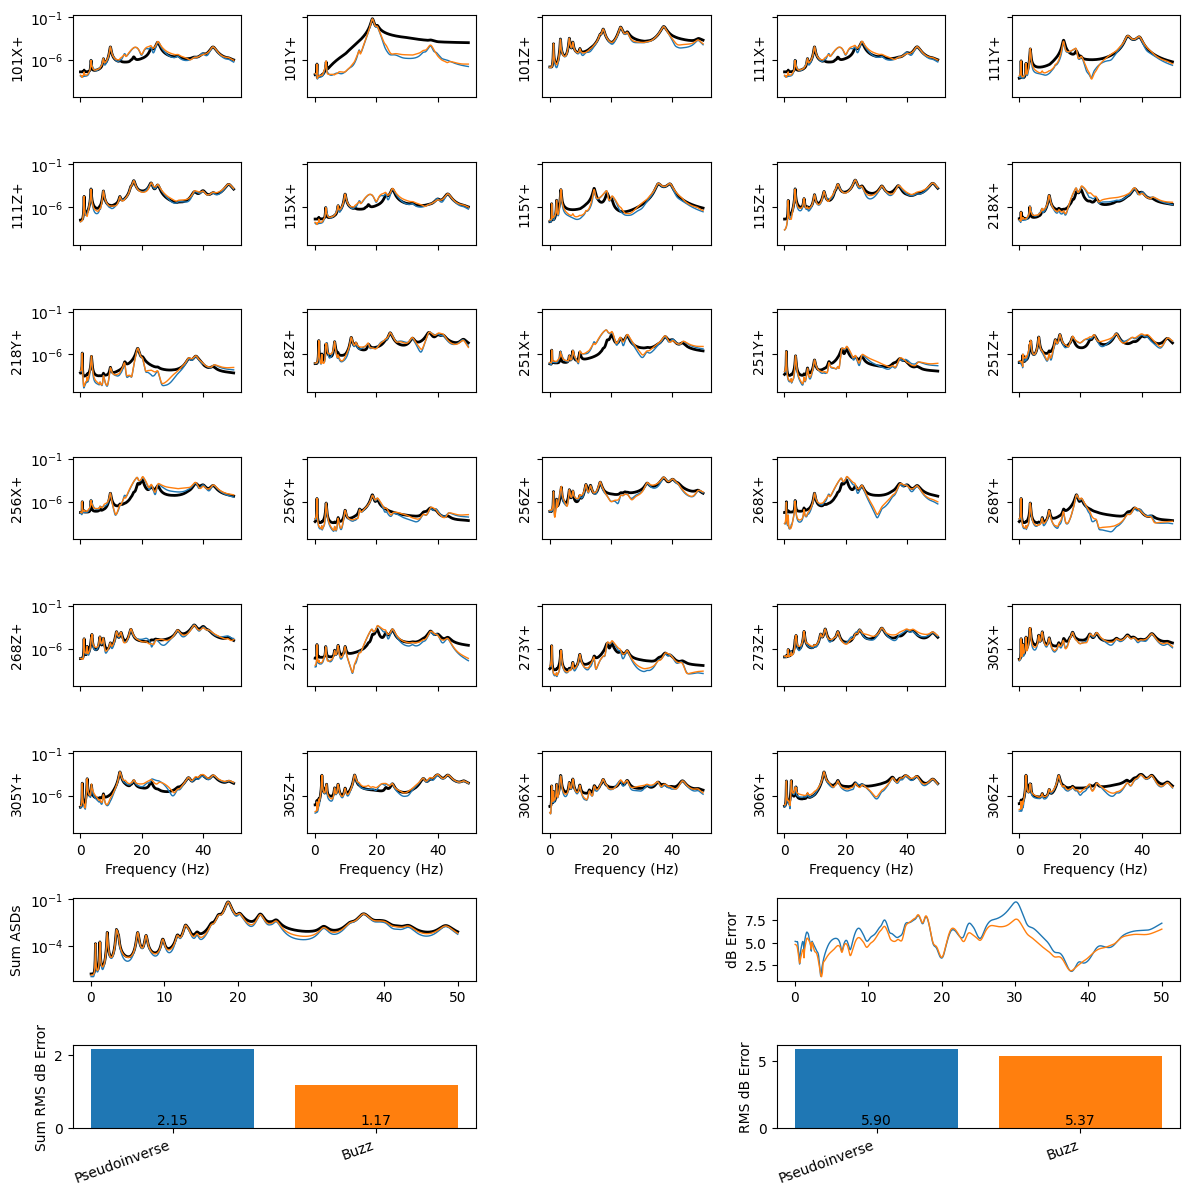

In [27]:
environment_specification.error_summary(Pseudoinverse=control_predictions,
                                        Buzz=control_predictions_buzz,
                                        figure_kwargs={'figsize':(12,12)});

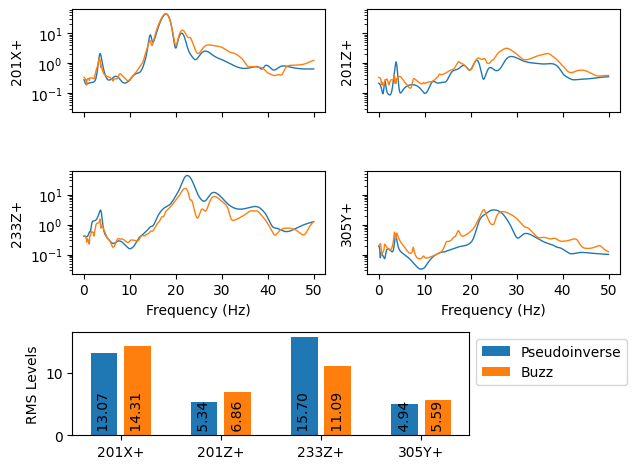

In [28]:
sdpy.data.PowerSpectralDensityArray.compare_asds(Pseudoinverse=input_cpsd,
                                                 Buzz=input_cpsd_buzz)

The results from the buzz test approach show more accuracy with less force
required on average, which makes this approach very attractive.  Note, however, that the
error metrics considered here only consider the level and ignore the relationships
between control degrees of freedom that will certainly be degraded due to their
modification.

## Running a Test

With a desired input PSD matrix developed, we will generally want to run the
test.  This will generally consist of generating time histories to play to the
shakers that satisfy the desired input PSDs.  SDynPy makes it easy to generate
time histories from a PSD matrix using the
[`generate_time_history`](#api:sdynpy.PowerSpectralDensityArray.generate_time_history)
method of the
[`PowerSpectralDensityArray`](#api:sdynpy.PowerSpectralDensityArray)
class.  Here we can specify the length of the signal we wish to generate,
and also specify an output oversampling as well, which is useful for integrating
equations of motion accurately, which we will do here to simulate the running
of a test.  We will generate a 1000 second signal with 10x oversampling for
accurate integration.  This will return a
[`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray)
object containing the time response that can be played to the shakers, or
alternatively, used to integrate equations of motion.

In [29]:
output_oversample = 10
input_signal = input_cpsd_buzz.generate_time_history(
    1000,output_oversample=output_oversample)

It is useful to check whether the time histories generated actually satisfy the
PSDs.  We can do this using the
[`cpsd`](#api:sdynpy.TimeHistoryArray.cpsd) method of the
[`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray) class,
which computes the PSD matrix from time data.

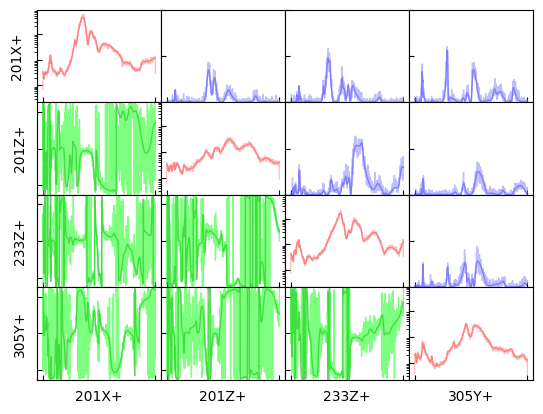

In [30]:
input_cpsd_buzz_check = input_signal.downsample(output_oversample).cpsd(
    frequencies.size*2, 0.5,'hann')
input_cpsd_buzz.plot_magnitude_coherence_phase(input_cpsd_buzz_check,
                                                magnitude_plot_kwargs={'linewidth':1,'alpha':0.5},
                                                coherence_plot_kwargs={'linewidth':1,'alpha':0.5},
                                                angle_plot_kwargs={'linewidth':1,'alpha':0.5})

Given that the generated time histories show good agreement to the desired PSDs,
we can now run the test with these time histories.  In this case, we will simply
use the forces to integrate the equations of motion to simulate the response of
the component using the
[`System.time_integrate`](#api:sdynpy.System.time_integrate)
of the [`System`](#api:sdynpy.System) object.

We can then downsample back to the non-oversampled rate and compute PSDs from
the responses.

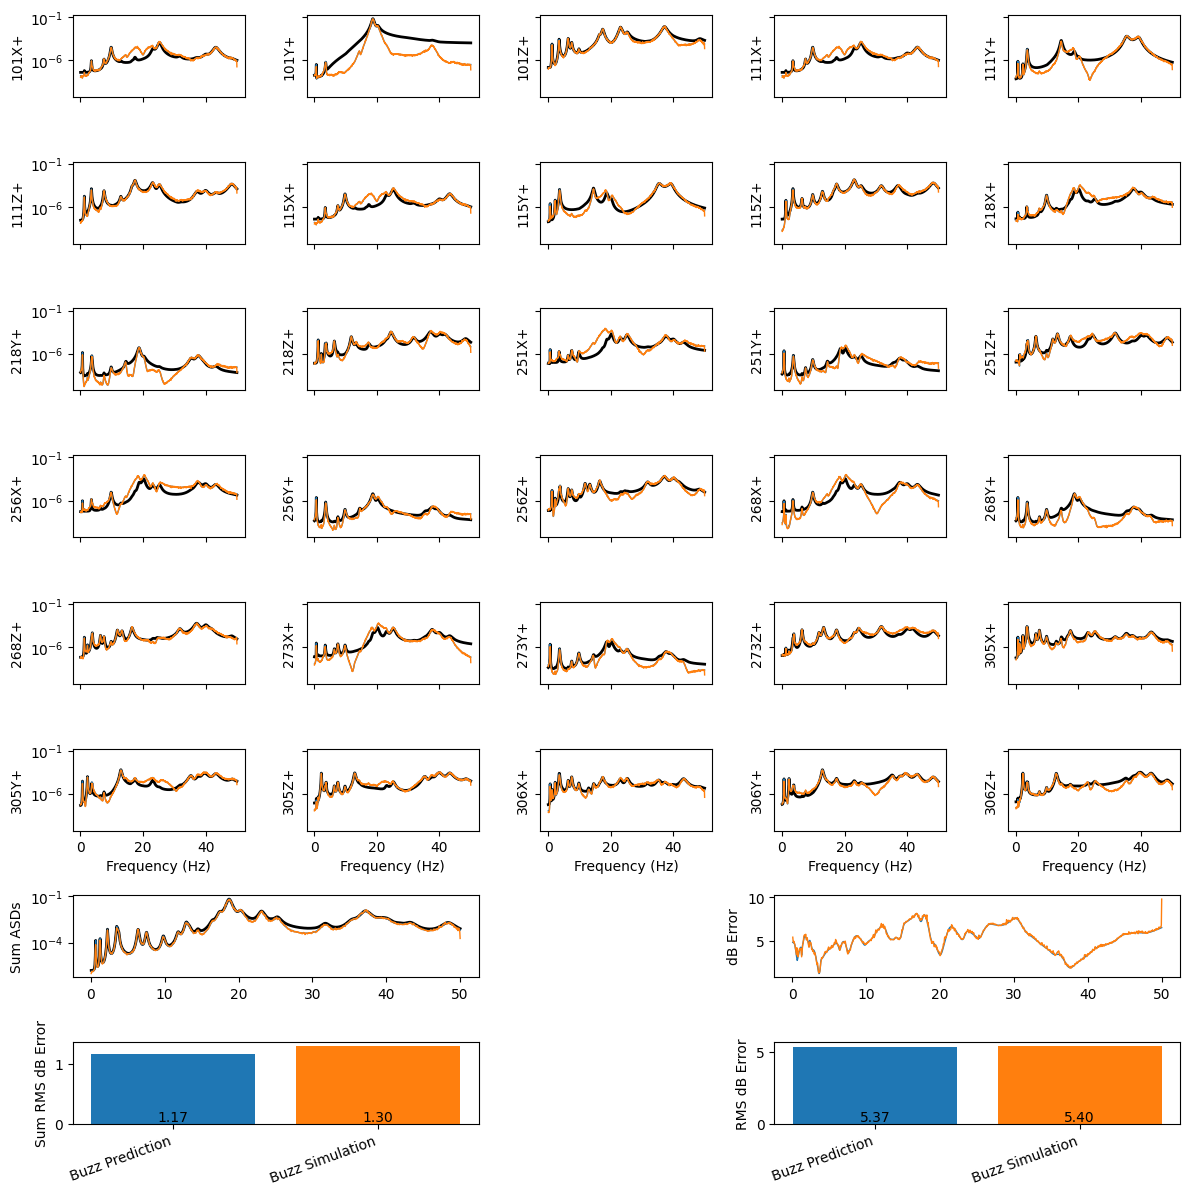

In [31]:
responses = modal_system.time_integrate(
    input_signal,
    {2:control_dofs.flatten()}) # 2 for acceleration

control_buzz = responses.downsample(output_oversample).cpsd(
    frequencies.size*2, 0.5,'hann')
# Throw out the first frequency line to make it consistent with the specification
control_buzz = control_buzz.idx_by_el[1:]

environment_specification.error_summary(Buzz_Prediction=control_predictions_buzz,
                                        Buzz_Simulation=control_buzz,
                                        figure_kwargs={'figsize':(12,12)});

The responses from the simulated tests match very well to those predicted from
the initial analysis.

## Summary

This tutorial walked through some of the workflow steps in performing MIMO
vibration control.  It introduced the
[`PowerSpectralDensityArray`](#api:sdynpy.PowerSpectralDensityArray)
class, which has several useful features for analyzing MIMO vibration data.  The
MIMO control problem can be simulated using the
[`mimo_inverse`](#api:sdynpy.PowerSpectralDensityArray.mimo_inverse)
and 
[`mimo_forward`](#api:sdynpy.PowerSpectralDensityArray.mimo_forward)
methods to identify the proper inputs and then apply those inputs, respectively.

Several methods of tuning the vibration control were investigated, including
regularization, weighting, and specification modification.  A test was then
simulated by integrating equations of motion, which provided good agreement to
the predicted responses.